<a href="https://colab.research.google.com/github/BintangPancahaya/PemMes_2026/blob/main/Kuis1/KUIS1_244107020115_BintangPancahaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

df.info()

print("\nStatistik deskriptif:")
display(df.describe(include='all'))

print("\nJumlah nilai yang hilang tiap kolom:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Statistik deskriptif:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,4
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,24720
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN



Jumlah nilai yang hilang tiap kolom:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [8]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

missing_cols = df.columns[df.isnull().any()]
print("Kolom dengan missing value:", list(missing_cols))

print("\nCek ulang missing value setelah imputasi:")
print(df.isnull().sum())

Kolom dengan missing value: ['workclass', 'occupation', 'native-country']

Cek ulang missing value setelah imputasi:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [9]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

categorical_cols = df.select_dtypes(include='object').columns
print("Fitur kualitatif:", list(categorical_cols))

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

df['income'] = df['income'].str.replace('.', '', regex=False).str.strip()

for col in categorical_cols:
    print(f"\nKolom: {col}")
    print(df[col].value_counts())

threshold = 5
for col in categorical_cols:
    counts = df[col].value_counts()
    rare_labels = counts[counts < threshold].index
    if len(rare_labels) > 0:
        df[col] = df[col].replace(rare_labels, 'Others')
        print(f"Kolom '{col}': {list(rare_labels)} -> diganti 'Others'")

print("\nUnique value setelah pembersihan:")
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Fitur kualitatif: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Kolom: workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
nan                   963
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Kolom: education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Kolom: marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated    

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

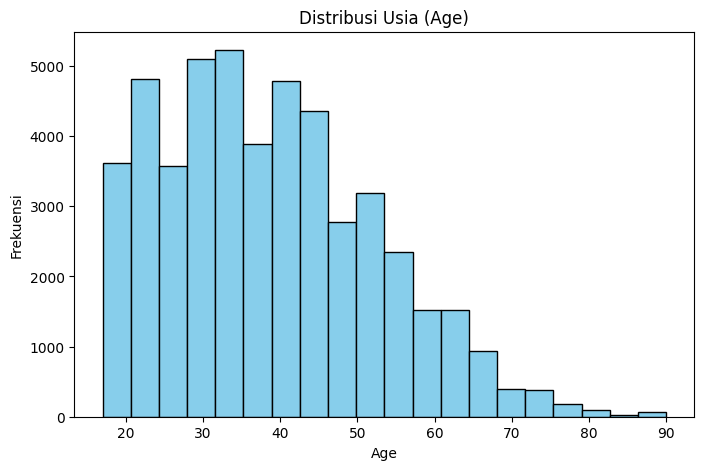

In [10]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribusi Usia (Age)")
plt.xlabel("Age")
plt.ylabel("Frekuensi")
plt.show()

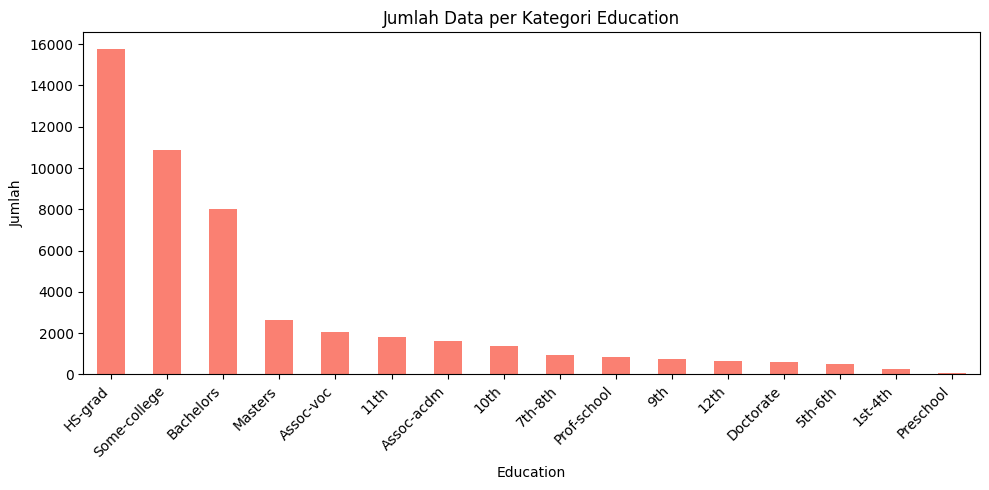

In [11]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(10, 5))
df['education'].value_counts().plot(kind='bar', color='salmon')
plt.title("Jumlah Data per Kategori Education")
plt.xlabel("Education")
plt.ylabel("Jumlah")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

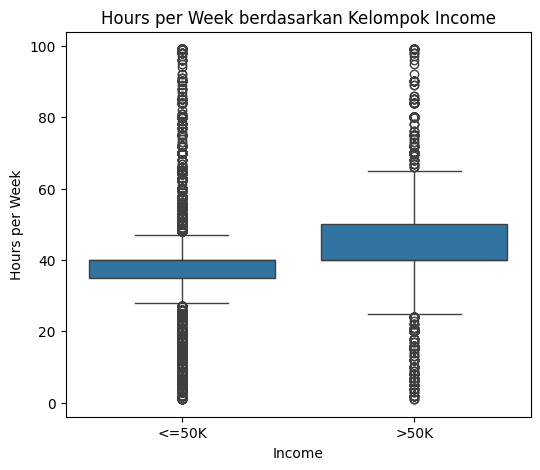

In [12]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title("Hours per Week berdasarkan Kelompok Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

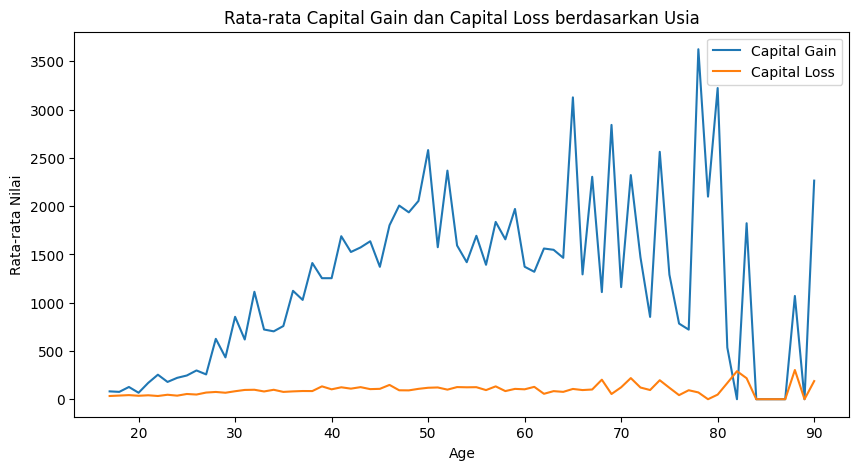

In [13]:
# Jawab 1.4 - Lineplot
age_group = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(age_group['age'], age_group['capital-gain'], label='Capital Gain')
plt.plot(age_group['age'], age_group['capital-loss'], label='Capital Loss')
plt.title("Rata-rata Capital Gain dan Capital Loss berdasarkan Usia")
plt.xlabel("Age")
plt.ylabel("Rata-rata Nilai")
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [14]:
# Jawab dengan komentar python

for income_group in df['income'].unique():
    subset = df[df['income'] == income_group]['hours-per-week']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = subset[(subset < lower_bound) | (subset > upper_bound)]
    print(f"Income: {income_group} -> Jumlah outlier: {len(outliers)}")
'''
1. Distribusi 'age' cenderung condong ke kanan, terlihat dari histogram Soal 1.1. Sebagian besar data terkonsentrasi pada usia produktif (sekitar 20-45 tahun), lalu jumlahnya semakin berkurang seiring bertambahnya usia.

2. Jika terdapat data yang hilang pada 'age', strategi yang lebih tepat adalah mengisi dengan median, bukan mean. Ini karena distribusinya tidak simetris.

3. Untuk income <=50K, jumlah outliner nya 11706. Sedangkan income >50K, jumlah outliner nya 781. Jadi kategori yang paling banyak memiliki outlier adalah income <=50K.
'''

Income: <=50K -> Jumlah outlier: 11706
Income: >50K -> Jumlah outlier: 781


"\n1. Distribusi 'age' cenderung condong ke kanan, terlihat dari histogram Soal 1.1. Sebagian besar data terkonsentrasi pada usia produktif (sekitar 20-45 tahun), lalu jumlahnya semakin berkurang seiring bertambahnya usia.\n\n2. Jika terdapat data yang hilang pada 'age', strategi yang lebih tepat adalah mengisi dengan median, bukan mean. Ini karena distribusinya tidak simetris.\n\n3. Untuk income <=50K, jumlah outliner nya 11706. Sedangkan income >50K, jumlah outliner nya 781. Jadi kategori yang paling banyak memiliki outlier adalah income <=50K.\n"

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [15]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

df['sex'] = df['sex'].map({'Male': 0, 'Female': 1})

df['income'] = df['income'].astype(str).str.replace('.', '', regex=False).str.strip()

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

print(df[['sex', 'income']].head())
print("\nUnique 'sex' setelah encoding:", df['sex'].unique())
print("Unique 'income' setelah encoding:", df['income'].unique())

   sex  income
0    0       0
1    0       0
2    0       0
3    0       0
4    1       0

Unique 'sex' setelah encoding: [0 1]
Unique 'income' setelah encoding: [0 1]


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

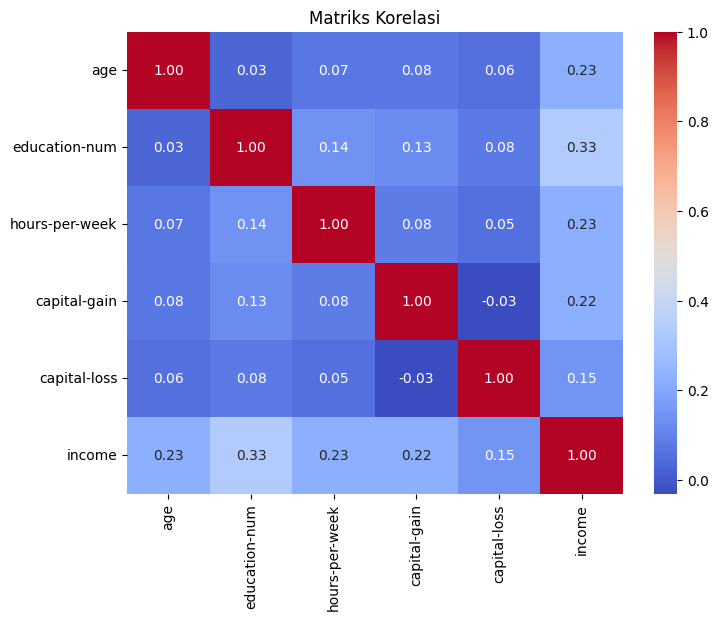

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income          0.230369       0.332613        0.227687      0.223013   

                capital-loss    income  
age                 0.056944  0.230369  
education-num       0.080972  0.332613  
hours-per-week      0.054467  0.227687  
capital-gain       -0.031441  0.223013  
capital-loss        1.000000  0.147554  
income              0.147554  1.000000  


In [24]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

cols_corr = ['age', 'education-num', 'hours-per-week',
             'capital-gain', 'capital-loss', 'income']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriks Korelasi")
plt.show()

print(corr_matrix)

In [27]:
# Hasil analisis jelaskan pada cell ini
'''
Berdasarkan matriks korelasi di atas
- education-num memiliki korelasi positif paling kuat terhadap
  income. Artinya semakin tinggi tingkat pendidikan seseorang, semakin
  besar kemungkinan penghasilannya termasuk kategori '>50K'.
- age dan hours-per-week juga berkorelasi positif dengan income.
- capital-gain dan capital-loss cenderung berkorelasi lemah dengan
  variabel lain, karena sebagian besar orang bernilai 0 pada kedua
  kolom tersebut (jarang terjadi transaksi capital gain/loss).
'''


"\nBerdasarkan matriks korelasi di atas\n- education-num memiliki korelasi positif paling kuat terhadap\n  income. Artinya semakin tinggi tingkat pendidikan seseorang, semakin\n  besar kemungkinan penghasilannya termasuk kategori '>50K'.\n- age dan hours-per-week juga berkorelasi positif dengan income.\n- capital-gain dan capital-loss cenderung berkorelasi lemah dengan\n  variabel lain, karena sebagian besar orang bernilai 0 pada kedua\n  kolom tersebut (jarang terjadi transaksi capital gain/loss).\n"

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [18]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


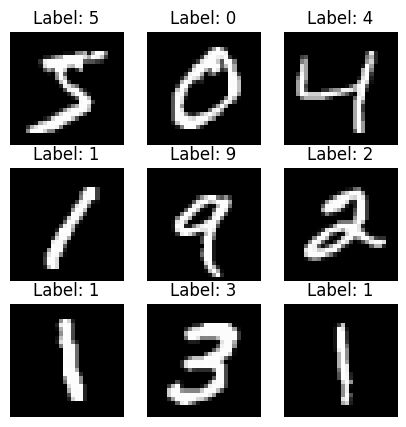

In [19]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape sebelum upsampling: (10000, 28, 28)
Shape sesudah upsampling: (10000, 32, 32)


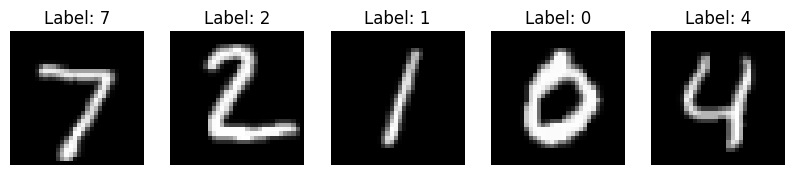

In [30]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

import cv2

X_test_upsampled = np.zeros((X_test.shape[0], 32, 32), dtype=np.uint8)

for i in range(X_test.shape[0]):
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32),
                                      interpolation=cv2.INTER_LINEAR)

print("Shape sebelum upsampling:", X_test.shape)
print("Shape sesudah upsampling:", X_test_upsampled.shape)

plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [31]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

X_test_normalized = X_test_upsampled.astype('float32') / 255.0

print("Nilai minimum setelah normalisasi:", X_test_normalized.min())
print("Nilai maksimum setelah normalisasi:", X_test_normalized.max())

Nilai minimum setelah normalisasi: 0.0
Nilai maksimum setelah normalisasi: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [32]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan

n_data = X_test_normalized.shape[0]
X_test_flatten = np.zeros((n_data, 32 * 32))

for i in range(n_data):
    X_test_flatten[i] = X_test_normalized[i].flatten()

print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape sesudah flatten (1 dimensi per data):", X_test_flatten.shape)

Shape sebelum flatten: (10000, 32, 32)
Shape sesudah flatten (1 dimensi per data): (10000, 1024)
